In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import cvxpy as cp
import warnings
warnings.filterwarnings('ignore')

root        = '../'
data_file   = '03_data/data_for_experiments/'
output_file = '05_output/'
start_date  = '200101'
end_date    = '202412'

os.makedirs(root + output_file, exist_ok=True)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [103]:
# # creat small data samples
# root        = '../'
# data_file   = '03_data/'

# all_signals = pd.read_parquet(root + data_file + 'WRDS/all_signals.parquet')
# all_signals.rename(columns={'yyyymm': 'date'}, inplace=True)
# all_signals['date'] = all_signals['date'].astype(str)
# all_signals = all_signals[(all_signals['date'] >= start_date) & (all_signals['date'] <= end_date)]
# os.makedirs(root + data_file + 'data_for_experiments/', exist_ok=True)
# all_signals.to_pickle(root + data_file + 'data_for_experiments/all_signals.pickle')
# del all_signals
# print('signals done')

# crsp_d = pd.read_parquet(root + data_file + 'WRDS/crsp_d.parquet')
# crsp_d = crsp_d[(crsp_d['date'] >= start_date[:4] + '-' + start_date[4:] + '-01') & (crsp_d['date'] <= end_date[:4] + '-' + end_date[4:] + '-31')]
# crsp_d.reset_index(drop=True, inplace=True)
# crsp_d.to_pickle(root + data_file + 'data_for_experiments/stock_daily.pickle')
# del crsp_d
# print('stock done')

In [104]:
# # generate monthly return data from daily return
# stock_daily = pd.read_pickle(root + data_file + 'stock_daily.pickle')
# stock_daily['month'] = stock_daily['date'].apply(lambda x: x[:7])
# stock_daily.sort_values(by=['permno', 'date'], inplace=True)
# stock_monthly = stock_daily.groupby(['permno', 'month']).agg(
#     ret       = ('ret',    'sum'),
#     prc       = ('prc',    'last'),
#     shrout    = ('shrout', 'last'),
#     vol       = ('vol',    'sum'),
#     shrcd     = ('shrcd',  'last'),
#     exchcd    = ('exchcd', 'last'),
# ).reset_index()
# stock_monthly['date'] = stock_monthly['month'].apply(lambda x: x.split('-')[0] + x.split('-')[1])
# stock_monthly = stock_monthly[['permno', 'date', 'ret', 'prc', 'shrout', 'vol', 'shrcd', 'exchcd']]
# os.makedirs(root + output_file + 'stock_monthly/', exist_ok=True)
# stock_monthly.to_pickle(root + output_file + 'stock_monthly/stock_monthly.pickle')

In [105]:
# import wrds
# db = wrds.Connection(wrds_username = 'dunran')
# sp500list = db.raw_sql("SELECT * FROM crsp.dsp500list")

In [2]:
signals = pd.read_pickle(root + data_file + 'all_signals.pickle')

In [3]:
stock_monthly = pd.read_pickle(root + output_file + 'stock_monthly/stock_monthly.pickle')
stock_monthly = stock_monthly[(stock_monthly['prc'] >= 5)]
# stock_monthly['mkcap'] = stock_monthly['prc'] * stock_monthly['shrout']
# stock_monthly['mkcap_rank'] = stock_monthly.groupby(['date'])['mkcap'].rank(ascending = False)
# stock_monthly = stock_monthly[(stock_monthly['mkcap_rank'] >= 0) & (stock_monthly['mkcap_rank'] <= 1000)]
# stock_monthly = stock_monthly[stock_monthly['permno'].isin(sp500list['permno'].tolist())]
stock_monthly = stock_monthly.merge(
    right = signals,
    on    = ['permno', 'date'],
    how   = 'left',
)
# cutoff_level = 0.1
# stock_monthly = stock_monthly.loc[:, stock_monthly.isnull().mean() <= cutoff_level].dropna(axis=0)

In [141]:
# for i in range(1, 10):
#     print(f'cut in {i*0.1:.2f} generates {stock_monthly.loc[:, stock_monthly.isnull().mean() <= i*0.1].dropna(axis = 0)['permno'].nunique():5} stocks')

In [5]:
DATE = stock_monthly['date'].sort_values().unique()
BACKTEST_START = DATE[0] 
BACKTEST_END   = '201912'
print(f'back test happens between {BACKTEST_START} and {BACKTEST_END}')
strategies = ['Single_Period_Markowitz', 'Equal_Weighted'] #+ [f'DRMV_\delta={i}' for i in [0.001, 0.005, 0.01]]


back test happens between 200101 and 201912


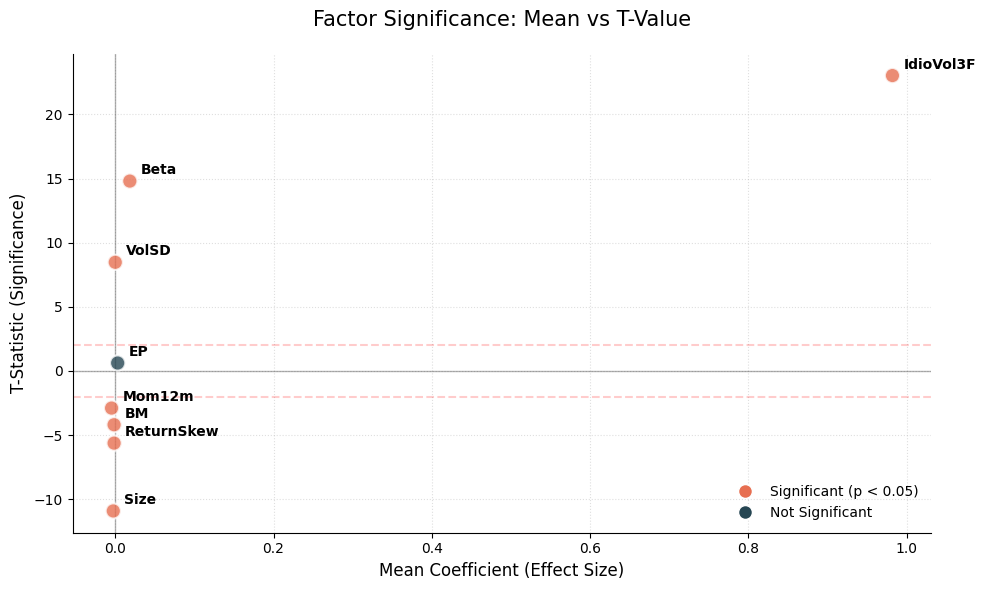

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import stats

def plot_factor_analysis(series_list, expected_mean=0):
    """
    针对输入的 List[pd.Series] 自动提取变量并绘制 均值 vs T值 散点图
    """
    # 1. 将 List 合并为一个 DataFrame，每一列代表一个变量，每一行代表一次采样/时间点
    df = pd.DataFrame(series_list)
    
    means = []
    t_stats = []
    p_values = []
    variable_names = df.columns # 自动获取 BM, Size, Mom12m 等变量名
    
    # 2. 遍历每个变量计算统计量
    for col in variable_names:
        data = df[col].dropna() # 排除缺失值
        m = data.mean()
        t_stat, p_val = stats.ttest_1samp(data, expected_mean)
        
        means.append(m)
        t_stats.append(t_stat)
        p_values.append(p_val)
    
    # 3. 开始绘图
    plt.figure(figsize=(10, 6), dpi=100)
    
    # 区分显著性颜色：P < 0.05 为橘红色，否则为深蓝色
    colors = ['#e76f51' if p < 0.05 else '#264653' for p in p_values]
    
    # 绘制散点
    plt.scatter(means, t_stats, c=colors, s=120, alpha=0.8, edgecolor='white', linewidth=1.5, zorder=3)
    
    # 4. 添加标注（变量名）
    for i, name in enumerate(variable_names):
        plt.annotate(name, (means[i], t_stats[i]), xytext=(8, 5), 
                     textcoords='offset points', fontsize=10, fontweight='bold')
    
    # 5. 添加辅助线
    plt.axhline(0, color='black', lw=1, alpha=0.3) # 0基准线
    plt.axvline(0, color='black', lw=1, alpha=0.3) # 0均值线
    # 标注 T=2 临界线（约等于 p=0.05）
    plt.axhline(2, color='red', linestyle='--', alpha=0.2)
    plt.axhline(-2, color='red', linestyle='--', alpha=0.2)
    
    # 6. 美化细节
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.grid(True, linestyle=':', alpha=0.4, zorder=0)
    
    plt.title(f'Factor Significance: Mean vs T-Value', pad=20, fontsize=15)
    plt.xlabel('Mean Coefficient (Effect Size)', fontsize=12)
    plt.ylabel('T-Statistic (Significance)', fontsize=12)
    
    # 图例
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='Significant (p < 0.05)', markerfacecolor='#e76f51', markersize=10),
        Line2D([0], [0], marker='o', color='w', label='Not Significant', markerfacecolor='#264653', markersize=10)
    ]
    plt.legend(handles=legend_elements, loc='best', frameon=False)

    plt.tight_layout()
    plt.show()

# --- 你可以直接这样调用 ---
plot_factor_analysis(params)

In [146]:
# from scipy import stats

# def perform_t_test(data, expected_mean=0):
#     # 执行单样本 t 检验
#     t_stat, p_value = stats.ttest_1samp(data, expected_mean)
    
#     print(f"--- 单样本 T 检验结果 ---")
#     print(f"T 统计量: {t_stat:.4f}")
#     print(f"P 值: {p_value:.4f}")
    
#     # 显著性水平通常取 0.05
#     if p_value < 0.01:
#         print("结论：在 0.01 显著性水平下，拒绝原假设（均值与预期有显著差异）。")
#     else:
#         print("结论：未能拒绝原假设（没有足够证据表明均值有显著差异）。")

# perform_t_test([t['ReturnSkew'] for t in tvalues], expected_mean=0)

In [ ]:
from scipy.optimize import minimize
def Equal_Weighted(returns_array):
    n_stocks = returns_array.shape[1]
    weight = 1.0 / n_stocks
    weights_col_vector = np.full((n_stocks, 1), weight)
    return weights_col_vector

def DRMV(returns, alpha_bar = 0.10 / 12, delta = 0.1, p = 2):
    n, d = returns.shape
    mu = np.mean(returns, axis=0)
    Sigma = returns.T @ returns / n
    V = Sigma - np.outer(mu, mu)
    
    def objective(phi):
        var_term = np.sqrt(phi.T @ V @ phi)
        reg_term = np.sqrt(delta) * np.linalg.norm(phi, ord=p)
        return float(var_term + reg_term)
    
    cons = [
        {'type': 'eq',   'fun': lambda phi: np.sum(phi) - 1.0},
        {'type': 'ineq', 'fun': lambda phi: mu @ phi - (alpha_bar + np.sqrt(delta) * np.linalg.norm(phi, ord=p))}
    ]
    
    res = minimize(objective, x0=np.ones(d)/d, method='SLSQP', constraints=cons,
        options={'disp': False, 'maxiter': 500, 'ftol': 1e-9},
        tol=1e-9
    )
    
    weights = res.x.reshape(-1, 1)
    weights = weights / np.sum(weights)
    return weights

In [ ]:
import cvxpy as cp

def DRMV_socp(returns, alpha_bar=0.10/12, delta=0.1, p=2):
    n, d = returns.shape
    mu = np.mean(returns, axis=0)
    Sigma = returns.T @ returns / n
    V = Sigma - np.outer(mu, mu)
    sqrt_delta = np.sqrt(delta)

    # Cholesky 分解，加微小正则化保证正定
    try:
        L = np.linalg.cholesky(V + 1e-8 * np.eye(d))
    except np.linalg.LinAlgError:
        L = np.linalg.cholesky(V + 1e-6 * np.eye(d))

    phi = cp.Variable(d)
    portfolio_std = cp.norm(L.T @ phi, 2)

    if p == 2:
        reg = sqrt_delta * cp.norm(phi, 2)
    elif p == 1:
        reg = sqrt_delta * cp.norm(phi, 1)
    else:
        reg = sqrt_delta * cp.norm(phi, p)

    objective = cp.Minimize(portfolio_std + reg)
    constraints = [
        cp.sum(phi) == 1,
        mu @ phi >= alpha_bar + reg,  # CVXPY 会自动展开
    ]

    prob = cp.Problem(objective, constraints)
    # CLARABEL 对 SOCP 非常快；备选 ECOS
    prob.solve(solver=cp.CLARABEL, verbose=False)
    weights = phi.value / phi.value.sum()
    return weights.reshape(-1, 1)

In [186]:
import time

def evaluate(data, T, N, iter_num, strategy_num, outer_bar):
    # port_ret = {s: [] for s in strategies}
    np.random.seed(45)
    port_ret = np.zeros((strategy_num, iter_num, data.shape[0] - T - 1))
    for s in range(iter_num):
        data_cut = data[:, np.random.permutation(data.shape[1])[:N]]
        for i in range(data_cut.shape[0] - T - 1):
            train_data = data_cut[i:(i+T), :]
            test_data  = data_cut[  i+T+1, :]
            
            w_ew = Equal_Weighted(train_data)
            w_1 = DRMV(train_data, 0.1/12, 0)
            w_2 = DRMV_socp(train_data, 0.1/12, 0.001)

            port_ret[0, s, i] = (test_data @ w_ew)[0]
            port_ret[1, s, i] = (test_data @ w_1)[0]
            port_ret[2, s, i] = (test_data @ w_2)[0]
        outer_bar.set_postfix(iter=f"{s+1}/{iter_num}") 

    return port_ret

In [198]:
from joblib import Parallel, delayed
from tqdm.auto import tqdm
import numpy as np

def _single_iter(data, T, N, strategy_num, s):
    rng = np.random.default_rng(45 + s)
    data_cut = data[:, rng.permutation(data.shape[1])[:N]]
    T_steps = data_cut.shape[0] - T - 1
    ret = np.zeros((strategy_num, T_steps))

    for i in range(T_steps):
        train = data_cut[i:i+T, :]
        test  = data_cut[i+T+1, :]

        w_ew = Equal_Weighted(train)
        w_1  = DRMV(train, 0.1/12, 0)
        w_2  = DRMV_socp(train, 0.1/12, 0.001)

        ret[0, i] = test @ w_ew.ravel()
        ret[1, i] = test @ w_1.ravel()
        ret[2, i] = test @ w_2.ravel()

    return ret  # shape: (strategy_num, T_steps)


def evaluate_parallel(data, T, N, iter_num, strategy_num, n_jobs=-1):
    with tqdm(total=iter_num, desc="Iterations", dynamic_ncols=True) as outer_bar:
        def tracked_iter(s):
            result = _single_iter(data, T, N, strategy_num, s)
            outer_bar.update(1)
            return result

        executor = Parallel(n_jobs=n_jobs, prefer='threads')
        results = executor(delayed(tracked_iter)(s) for s in range(iter_num))

    port_ret = np.stack(results, axis=1)  # (strategy_num, iter_num, T_steps)
    return port_ret

In [199]:
signal = 'Size'
data = stock_monthly.dropna(subset=['ret', signal]).pivot(index='date', columns='permno', values='ret')
data = data.sort_index().astype(float).values
signal_data = stock_monthly.dropna(subset=['ret', signal]).pivot(index='date', columns='permno', values=signal)
signal_data = signal_data.sort_index().astype(float).values

data = data[:, ~np.any(np.isnan(data), axis=0)]

signal_data = signal_data[:, ~np.any(np.isnan(signal_data), axis=0)]
data = data[:, np.argsort(signal_data[-2, :])[-400:]]

iter_num = 100
T = 12
strategy_num = 3
portfolio_size = [n for n in range(1, 5)]
port_ret = np.zeros((len(portfolio_size), strategy_num, iter_num, data.shape[0] - T - 1))

# outer_bar = tqdm(portfolio_size)
for N in portfolio_size:
    # port_ret[N-1] = evaluate(data, T, N, iter_num, strategy_num, outer_bar)
    port_ret[N-1] = evaluate_parallel(data, T, N, iter_num, strategy_num,)

sharpe = port_ret.mean(axis=3)*12 / (port_ret.std(axis=3)*np.sqrt(12))
mean_sharpe = sharpe.mean(axis=2)

Iterations:  42%|████▏     | 42/100 [00:34<00:48,  1.20it/s]


KeyboardInterrupt: 

In [193]:
port_ret.shape

(3, 3, 100, 275)

In [154]:
port_ret = np.load('../05_output/port_ret(12,5,100,3).npy')
sharpe = port_ret.mean(axis=3)*12 / (port_ret.std(axis=3)*np.sqrt(12))
mean_sharpe = sharpe.mean(axis=2)

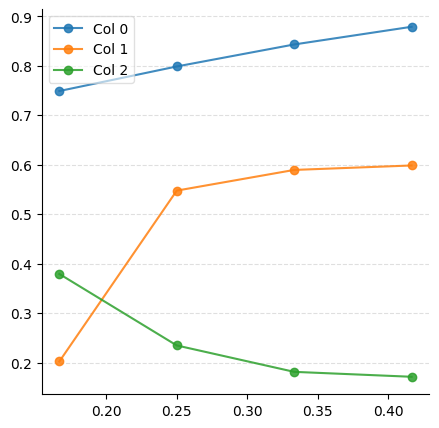

In [155]:
data = mean_sharpe[1:, :]
x = np.arange(2, data.shape[0] + 2) / T
fig, ax = plt.subplots(figsize=(5, 5))
for i, col in enumerate(data.T):
    ax.plot(x, col, linewidth=1.5, label=f'Col {i}', alpha=0.85, marker='o')

ax.legend(framealpha=0.6, loc='upper left')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)


In [ ]:
stock_monthly['ret_pred'] = stock_monthly.groupby(['permno'])['ret'].rolling(T).mean().droplevel(0)
stock_monthly['ret_pred_error'] = np.abs(stock_monthly.groupby('permno')['ret'].shift(-1) - stock_monthly['ret_pred'])
import statsmodels.api as sm
params = []

characteristic = ['BM', 'Size', 'Mom12m', 'Beta', 'ReturnSkew', 'VolSD', 'IdioVol3F', 'EP']
for i, date in enumerate(DATE):
    if i <= 120 or stock_monthly[stock_monthly['date'] == date].dropna(subset=['ret_pred_error', *characteristic]).shape[0] == 0:
        continue
    print('\r', date, end = '')
    model = sm.OLS(
        endog=stock_monthly[stock_monthly['date'] == date].dropna(subset=['ret_pred_error', *characteristic])['ret_pred_error'], 
        exog=sm.add_constant(stock_monthly[stock_monthly['date'] == date].dropna(subset=['ret_pred_error', *characteristic])[characteristic])
    ).fit()
    params.append(model.params[characteristic])

 202411

In [137]:
data = stock_monthly[['permno', 'date', 'ret'] + ['Size', 'BM', 'Beta', 'IdioVol3F', 'Mom12m', 'BidAskSpread', 'RealizedVol']].dropna()
data['count'] = data.groupby('permno')['date'].transform('nunique')
data['prdret'] = data.groupby(['permno'])['ret'].rolling(T).mean().droplevel(0)

data['ret_group']    = data.groupby(['date'])['ret'].rank(pct=True) // 0.2
data['Size']         = data.groupby(['date'])['Size'].rank(pct=True) // 0.2
data['BM']           = data.groupby(['date'])['BM'].rank(pct=True)     // 0.2
data['Beta']         = data.groupby(['date'])['Beta'].rank(pct=True) // 0.2
data['IdioVol3F']    = data.groupby(['date'])['IdioVol3F'].rank(pct=True) // 0.2
data['Mom12m']       = data.groupby(['date'])['Mom12m'].rank(pct=True) // 0.2
data['BidAskSpread'] = data.groupby(['date'])['BidAskSpread'].rank(pct=True) // 0.2
data['RealizedVol']  = data.groupby(['date'])['RealizedVol'].rank(pct=True) // 0.2

def oos_r2(group):
    y_true = group['ret']
    y_pred = group['prdret']
    sse = np.sum((y_true - y_pred) ** 2)
    sst = np.sum(y_true ** 2)
    
    return 1 - (sse / sst) if sst != 0 else np.nan

group = ['Beta']
data = data.dropna().groupby(['date'] + group).apply(
    lambda x: pd.Series({
        'oos_r2': oos_r2(x),
        'n_stock': x['ret'].count()
    })
).reset_index()

In [138]:
import statsmodels.api as sm
model = sm.OLS(endog=data['oos_r2'], exog=sm.add_constant(pd.get_dummies(data['Beta'], drop_first=True).astype(int))).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 oos_r2   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     4.120
Date:                Thu, 09 Apr 2026   Prob (F-statistic):            0.00253
Time:                        20:20:23   Log-Likelihood:                 923.95
No. Observations:                1385   AIC:                            -1838.
Df Residuals:                    1380   BIC:                            -1812.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1061      0.007     14.198      0.0